# Análisis de Bajo Peso al Nacer — SIVIGILA (Medellín, 2011–2021)

Este notebook explora, limpia y analiza el conjunto de datos `sivigila_bpn.csv`, correspondiente a casos de **Bajo Peso al Nacer** reportados al Sistema de Vigilancia en Salud Pública (SIVIGILA) en la ciudad de Medellín.

**Contenido:**
1. Lectura y exploración inicial del dataset
2. Limpieza y transformación de los datos
3. Análisis de patrones y tendencias
4. Visualizaciones
5. Hallazgos y conclusiones

## 1. Lectura y exploración del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('sivigila_bpn.csv')
print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")
df.head()

Filas: 10187  |  Columnas: 19


,id,semana,edad_,uni_med_,sexo_,nombre_barrio,comuna,tipo_ss_,cod_ase_,fec_con_,ini_sin_,tip_cas_,pac_hos_,peso_nacer,talla_nacer,sem_gest,niv_edu_ma,evento,year_
0,1,41,28,1,M,Oriente,Manrique,N,"\""\""",01/01/1900,01/01/1900,4,1,2440,49,38,SD,BAJO PESO AL NACER,2011
1,2,41,17,1,F,SIN INFORMACION,SIN INFORMACION,S,EPS003,01/01/1900,01/01/1900,4,1,2490,46,37,SD,BAJO PESO AL NACER,2011
2,3,44,19,1,F,Villa del Socorro,Santa Cruz,S,EPS003,01/01/1900,01/01/1900,4,1,2290,47,37,SD,BAJO PESO AL NACER,2011
3,4,47,27,1,F,Las Independencias,San Javier,S,EPS003,01/01/1900,01/01/1900,4,1,2400,49,37,SD,BAJO PESO AL NACER,2011
4,5,47,23,1,F,Granizal,Popular,N,"\""\""",01/01/1900,01/01/1900,4,1,2240,47,38,SD,BAJO PESO AL NACER,2011


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10187 entries, 0 to 10186
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id             10187 non-null  int64
 1   semana         10187 non-null  int64
 2   edad_          10187 non-null  int64
 3   uni_med_       10187 non-null  int64
 4   sexo_          10187 non-null  str  
 5   nombre_barrio  10187 non-null  str  
 6   comuna         10187 non-null  str  
 7   tipo_ss_       10187 non-null  str  
 8   cod_ase_       10187 non-null  str  
 9   fec_con_       10187 non-null  str  
 10  ini_sin_       10187 non-null  str  
 11  tip_cas_       10187 non-null  int64
 12  pac_hos_       10187 non-null  int64
 13  peso_nacer     10187 non-null  str  
 14  talla_nacer    10187 non-null  str  
 15  sem_gest       10187 non-null  str  
 16  niv_edu_ma     10187 non-null  str  
 17  evento         10187 non-null  str  
 18  year_          10187 non-null  int64
dtypes: int64(7), st

In [3]:
# Diccionario rápido de columnas relevantes
diccionario = {
    'id': 'Identificador del caso',
    'semana': 'Semana epidemiológica de notificación',
    'edad_': 'Edad de la madre (años)',
    'sexo_': 'Sexo del recién nacido (M/F)',
    'nombre_barrio': 'Barrio de residencia',
    'comuna': 'Comuna de residencia (Medellín)',
    'tipo_ss_': 'Tipo de seguridad social',
    'cod_ase_': 'Código de la EPS/aseguradora',
    'fec_con_': 'Fecha de consulta',
    'ini_sin_': 'Fecha de inicio de síntomas',
    'pac_hos_': 'Paciente hospitalizado (1=Sí, 2=No)',
    'peso_nacer': 'Peso al nacer (gramos)',
    'talla_nacer': 'Talla al nacer (cm)',
    'sem_gest': 'Semanas de gestación',
    'niv_edu_ma': 'Nivel educativo de la madre (código)',
    'year_': 'Año de notificación',
}
pd.Series(diccionario, name='descripción').to_frame()

,descripción
id,Identificador del caso
semana,Semana epidemiológica de notificación
edad_,Edad de la madre (años)
sexo_,Sexo del recién nacido (M/F)
nombre_barrio,Barrio de residencia
comuna,Comuna de residencia (Medellín)
tipo_ss_,Tipo de seguridad social
cod_ase_,Código de la EPS/aseguradora
fec_con_,Fecha de consulta
ini_sin_,Fecha de inicio de síntomas


In [4]:
# Valores nulos declarados y duplicados
print("Nulos por columna:")
print(df.isna().sum()[df.isna().sum() > 0])
print()
print("Filas duplicadas (todas las columnas):", df.duplicated().sum())
print("IDs duplicados:", df['id'].duplicated().sum())

Nulos por columna:
Series([], dtype: int64)

Filas duplicadas (todas las columnas): 0
IDs duplicados: 0


## 2. Limpieza de datos

Se detectaron varios problemas de calidad típicos de datos capturados manualmente:

- `peso_nacer`, `talla_nacer` y `sem_gest` están como texto, con el código **"SD"** (Sin Dato) como faltante, y `talla_nacer` usa **coma decimal** (`44,5`) en vez de punto.
- `comuna` tiene inconsistencias de mayúsculas/minúsculas (`SIN INFORMACION`, `Sin informacion`, `Corregimiento De Santa Elena` vs `Corregimiento de Santa Elena`).
- `fec_con_` e `ini_sin_` son fechas en texto, con `01/01/1900` como marcador de fecha no disponible.
- `niv_edu_ma` usa códigos numéricos + `"SD"`.
- `cod_ase_` usa el literal `""` como marcador de "sin información".

A continuación se corrige cada uno de estos casos.

In [5]:
dfc = df.copy()

# --- Variables numéricas mal tipadas ---
# talla_nacer usa coma decimal -> normalizar a punto
dfc['talla_nacer'] = dfc['talla_nacer'].str.replace(',', '.', regex=False)

for col in ['peso_nacer', 'talla_nacer', 'sem_gest']:
    dfc[col] = pd.to_numeric(dfc[col], errors='coerce')  # 'SD' -> NaN

print("Valores no numéricos convertidos a NaN:")
print(dfc[['peso_nacer', 'talla_nacer', 'sem_gest']].isna().sum())

Valores no numéricos convertidos a NaN:
peso_nacer     2
talla_nacer    2
sem_gest       2
dtype: int64


In [6]:
# --- Normalización de 'comuna' ---
dfc['comuna'] = dfc['comuna'].str.strip().str.title()
dfc['comuna'] = dfc['comuna'].replace({
    'Sin Informacion': 'Sin Información',
    'Corregimiento De Santa Elena': 'Corregimiento De Santa Elena',
})
# unificar variantes de tildes/espacios
dfc['comuna'] = dfc['comuna'].str.replace('Informacion', 'Información', regex=False)

print(dfc['comuna'].value_counts())

comuna
Manrique                          858
Robledo                           820
Villa Hermosa                     784
Popular                           768
San Javier                        733
Doce De Octubre                   710
Belen                             644
Buenos Aires                      613
Aranjuez                          595
Santa Cruz                        552
Sin Información                   420
Castilla                          405
La Candelaria                     400
El Poblado                        356
San Antonio De Prado              323
Corregimiento De San Cristobal    309
Guayabal                          231
Laureles                          226
La America                        220
Altavista                         120
Corregimiento De Santa Elena       87
San Sebastian De Palmitas          13
Name: count, dtype: int64


In [7]:
# --- Fechas: 01/01/1900 es un marcador de "sin dato" ---
for col in ['fec_con_', 'ini_sin_']:
    dfc[col] = pd.to_datetime(dfc[col], format='%d/%m/%Y', errors='coerce')
    dfc.loc[dfc[col].dt.year == 1900, col] = pd.NaT

print(dfc[['fec_con_', 'ini_sin_']].isna().sum())

fec_con_      124
ini_sin_    10181
dtype: int64


In [8]:
# --- Nivel educativo de la madre: mapear códigos a etiquetas ---
mapa_educacion = {
    '1': 'Ninguno', '2': 'Primaria', '3': 'Secundaria',
    '4': 'Técnico/Tecnológico', '5': 'Universitario', 'SD': np.nan,
}
dfc['niv_edu_ma'] = dfc['niv_edu_ma'].map(mapa_educacion)

# --- Código de aseguradora: '""' -> sin información ---
dfc['cod_ase_'] = dfc['cod_ase_'].replace('""', np.nan).replace('\"\"', np.nan)

# --- Sexo y tipo de seguridad social con etiquetas legibles ---
dfc['sexo_'] = dfc['sexo_'].map({'M': 'Masculino', 'F': 'Femenino'})
mapa_ss = {'C': 'Contributivo', 'S': 'Subsidiado', 'N': 'No asegurado',
           'E': 'Excepción', 'P': 'Particular', 'I': 'No definido'}
dfc['tipo_ss_'] = dfc['tipo_ss_'].map(mapa_ss)

dfc[['sexo_', 'tipo_ss_', 'niv_edu_ma']].head()

,sexo_,tipo_ss_,niv_edu_ma
0,Masculino,No asegurado,NaN
1,Femenino,Subsidiado,NaN
2,Femenino,Subsidiado,NaN
3,Femenino,Subsidiado,NaN
4,Femenino,No asegurado,NaN


In [9]:
# --- Columnas sin variación (no aportan al análisis) ---
cols_constantes = [c for c in dfc.columns if dfc[c].nunique(dropna=False) == 1]
print("Columnas constantes:", cols_constantes)
dfc = dfc.drop(columns=cols_constantes)

# --- Clasificación clínica del peso al nacer ---
def clasificar_peso(p):
    if pd.isna(p):
        return np.nan
    if p < 1000:
        return 'Extremadamente bajo (<1000g)'
    elif p < 1500:
        return 'Muy bajo (1000-1499g)'
    else:
        return 'Bajo peso (1500-2499g)'

dfc['clasificacion_peso'] = dfc['peso_nacer'].apply(clasificar_peso)

print("Dataset limpio:", dfc.shape)
dfc.head()

Columnas constantes: ['uni_med_', 'tip_cas_', 'evento']
Dataset limpio: (10187, 17)


,id,semana,edad_,sexo_,nombre_barrio,comuna,tipo_ss_,cod_ase_,fec_con_,ini_sin_,pac_hos_,peso_nacer,talla_nacer,sem_gest,niv_edu_ma,year_,clasificacion_peso
0,1,41,28,Masculino,Oriente,Manrique,No asegurado,"\""\""",NaT,NaT,1,2440.0,49.0,38.0,NaN,2011,Bajo peso (1500-2499g)
1,2,41,17,Femenino,SIN INFORMACION,Sin Información,Subsidiado,EPS003,NaT,NaT,1,2490.0,46.0,37.0,NaN,2011,Bajo peso (1500-2499g)
2,3,44,19,Femenino,Villa del Socorro,Santa Cruz,Subsidiado,EPS003,NaT,NaT,1,2290.0,47.0,37.0,NaN,2011,Bajo peso (1500-2499g)
3,4,47,27,Femenino,Las Independencias,San Javier,Subsidiado,EPS003,NaT,NaT,1,2400.0,49.0,37.0,NaN,2011,Bajo peso (1500-2499g)
4,5,47,23,Femenino,Granizal,Popular,No asegurado,"\""\""",NaT,NaT,1,2240.0,47.0,38.0,NaN,2011,Bajo peso (1500-2499g)


In [10]:
# --- Outliers / rangos fisiológicamente imposibles ---
print(dfc[['edad_', 'peso_nacer', 'talla_nacer', 'sem_gest']].describe())
# Edad materna: valores muy bajos podrían ser errores de captura
print()
print("Casos con edad materna < 10 años:", (dfc['edad_'] < 10).sum())

              edad_    peso_nacer   talla_nacer      sem_gest
count  10187.000000  10185.000000  10185.000000  10185.000000
mean      25.572593   2313.819048     46.141915     37.654885
std        6.749109    167.324251      2.054569      0.869416
min        5.000000    900.000000     30.000000     37.000000
25%       20.000000   2240.000000     45.000000     37.000000
50%       25.000000   2360.000000     46.000000     37.000000
75%       30.000000   2440.000000     47.000000     38.000000
max       57.000000   2499.000000     55.000000     45.000000

Casos con edad materna < 10 años: 7


## 3. Análisis de patrones y tendencias

### 3.1 Evolución de los casos por año

In [11]:
casos_por_anio = dfc['year_'].value_counts().sort_index()
casos_por_anio

year_
2011      96
2012     708
2013    1049
2014    1078
2015     983
2016    1002
2017    1057
2018    1147
2019    1054
2020     921
2021    1092
Name: count, dtype: int64

### 3.2 Distribución geográfica (comunas)

In [12]:
top_comunas = dfc['comuna'].value_counts().head(10)
top_comunas

comuna
Manrique           858
Robledo            820
Villa Hermosa      784
Popular            768
San Javier         733
Doce De Octubre    710
Belen              644
Buenos Aires       613
Aranjuez           595
Santa Cruz         552
Name: count, dtype: int64

### 3.3 Peso al nacer: estadísticas y clasificación clínica

In [13]:
print(dfc['peso_nacer'].describe())
print()
print(dfc['clasificacion_peso'].value_counts())

count    10185.000000
mean      2313.819048
std        167.324251
min        900.000000
25%       2240.000000
50%       2360.000000
75%       2440.000000
max       2499.000000
Name: peso_nacer, dtype: float64

clasificacion_peso
Bajo peso (1500-2499g)          10164
Muy bajo (1000-1499g)              20
Extremadamente bajo (<1000g)        1
Name: count, dtype: int64


### 3.4 Relación entre edad materna, nivel educativo y peso al nacer

In [14]:
peso_por_edu = dfc.groupby('niv_edu_ma')['peso_nacer'].mean().sort_values()
peso_por_edu

niv_edu_ma
Técnico/Tecnológico    2236.419580
Ninguno                2300.489503
Secundaria             2313.029486
Primaria               2316.478996
Universitario          2396.384615
Name: peso_nacer, dtype: float64

In [15]:
# Correlación entre semanas de gestación y peso al nacer
correlacion = dfc[['sem_gest', 'peso_nacer', 'talla_nacer', 'edad_']].corr()
correlacion

,sem_gest,peso_nacer,talla_nacer,edad_
sem_gest,1.000000,0.189391,0.194143,-0.048151
peso_nacer,0.189391,1.000000,0.427831,-0.018708
talla_nacer,0.194143,0.427831,1.000000,-0.022338
edad_,-0.048151,-0.018708,-0.022338,1.000000


### 3.5 Estacionalidad por semana epidemiológica

In [16]:
casos_por_semana = dfc['semana'].value_counts().sort_index()
casos_por_semana.describe()

count     53.000000
mean     192.207547
std       31.943675
min       29.000000
25%      175.000000
50%      195.000000
75%      211.000000
max      248.000000
Name: count, dtype: float64

## 4. Visualizaciones

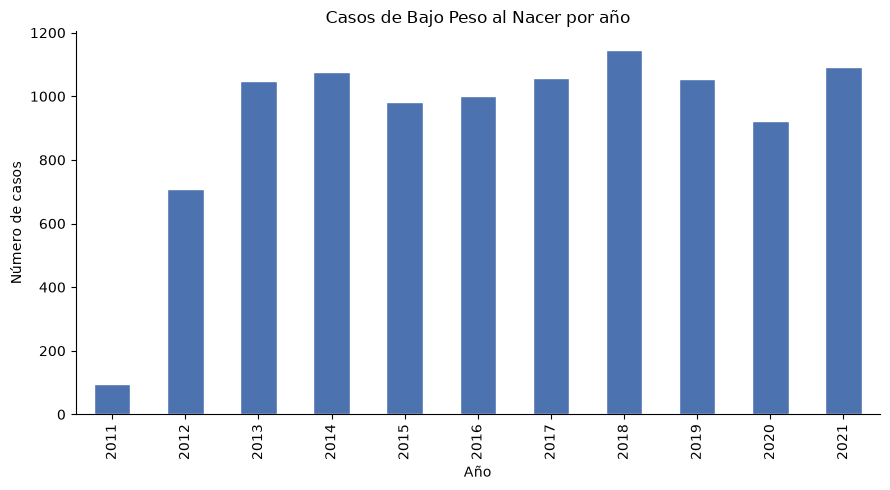

In [17]:
fig, ax = plt.subplots()
casos_por_anio.plot(kind='bar', ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Casos de Bajo Peso al Nacer por año')
ax.set_xlabel('Año')
ax.set_ylabel('Número de casos')
plt.tight_layout()
plt.show()

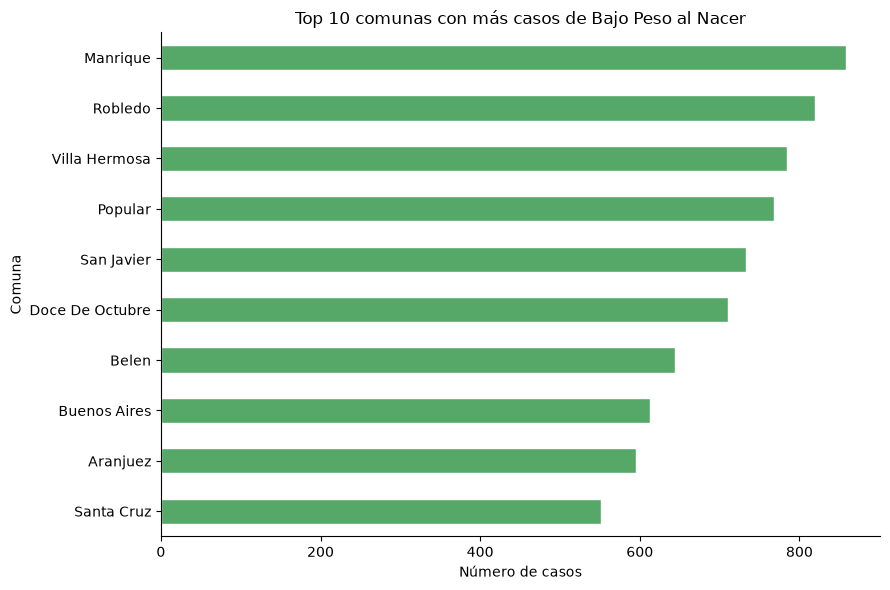

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))
top_comunas.sort_values().plot(kind='barh', ax=ax, color='#55A868', edgecolor='white')
ax.set_title('Top 10 comunas con más casos de Bajo Peso al Nacer')
ax.set_xlabel('Número de casos')
ax.set_ylabel('Comuna')
plt.tight_layout()
plt.show()

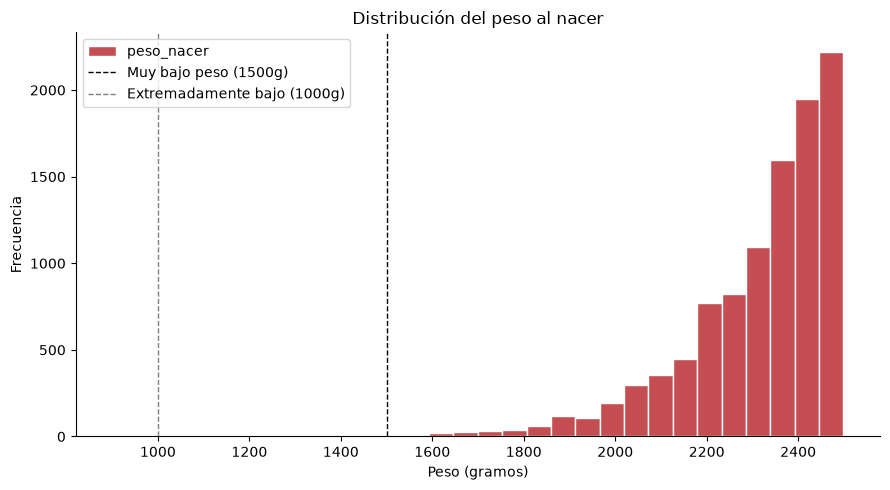

In [19]:
fig, ax = plt.subplots()
dfc['peso_nacer'].dropna().plot(kind='hist', bins=30, ax=ax, color='#C44E52', edgecolor='white')
ax.axvline(1500, color='black', linestyle='--', linewidth=1, label='Muy bajo peso (1500g)')
ax.axvline(1000, color='gray', linestyle='--', linewidth=1, label='Extremadamente bajo (1000g)')
ax.set_title('Distribución del peso al nacer')
ax.set_xlabel('Peso (gramos)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

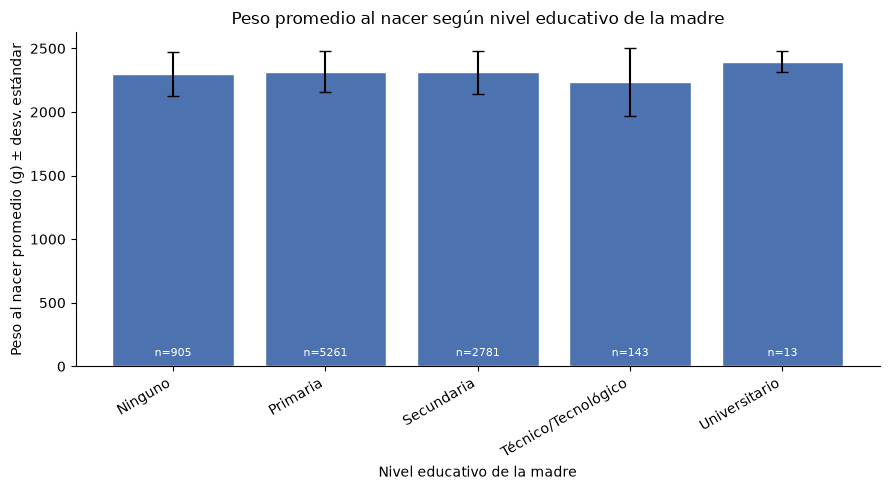

In [20]:
orden_edu = ['Ninguno', 'Primaria', 'Secundaria', 'Técnico/Tecnológico', 'Universitario']
resumen_edu = dfc.groupby('niv_edu_ma')['peso_nacer'].agg(['mean', 'std', 'count']).reindex(orden_edu)

fig, ax = plt.subplots()
barras = ax.bar(orden_edu, resumen_edu['mean'], yerr=resumen_edu['std'],
                 color='#4C72B0', edgecolor='white', capsize=4)
for barra, n in zip(barras, resumen_edu['count']):
    ax.text(barra.get_x() + barra.get_width() / 2, 60, f"n={int(n)}",
            ha='center', va='bottom', fontsize=8, color='white')
ax.set_title('Peso promedio al nacer según nivel educativo de la madre')
ax.set_xlabel('Nivel educativo de la madre')
ax.set_ylabel('Peso al nacer promedio (g) ± desv. estándar')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

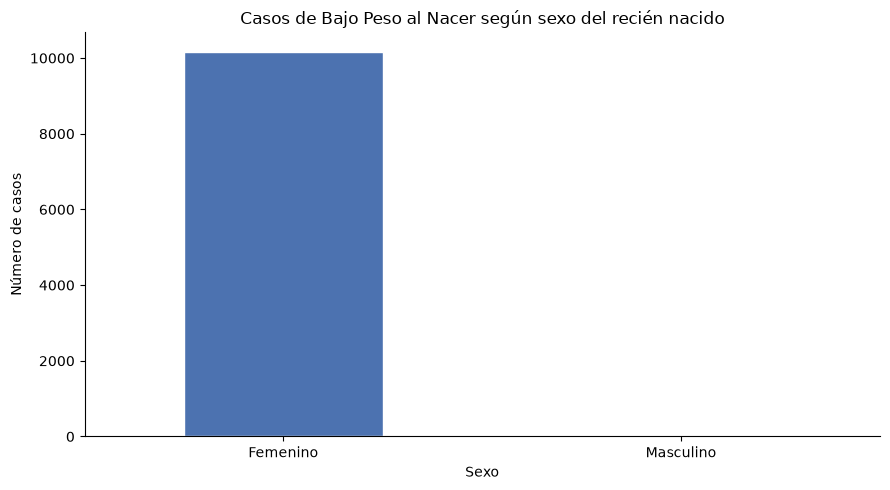

In [21]:
fig, ax = plt.subplots()
dfc['sexo_'].value_counts().plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white')
ax.set_title('Casos de Bajo Peso al Nacer según sexo del recién nacido')
ax.set_xlabel('Sexo')
ax.set_ylabel('Número de casos')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

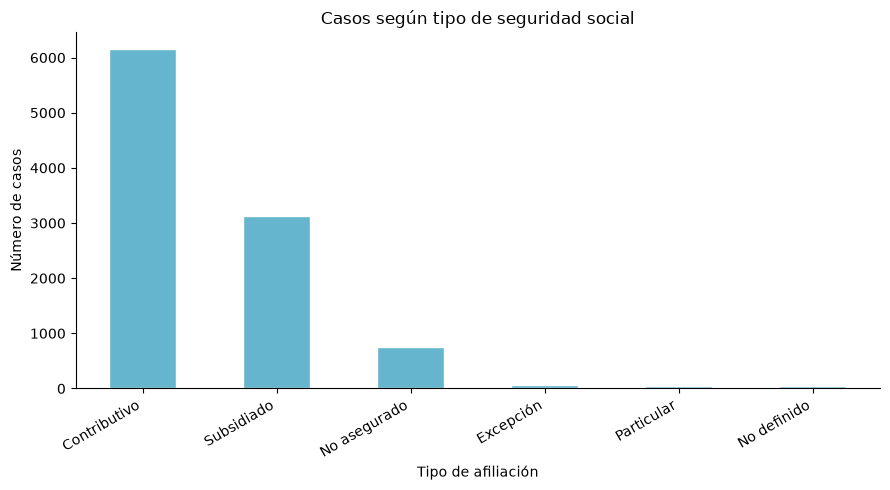

In [22]:
fig, ax = plt.subplots()
dfc['tipo_ss_'].value_counts().plot(kind='bar', ax=ax, color='#64B5CD', edgecolor='white')
ax.set_title('Casos según tipo de seguridad social')
ax.set_xlabel('Tipo de afiliación')
ax.set_ylabel('Número de casos')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 5. Hallazgos y conclusiones

**Calidad de los datos**
- El dataset requirió limpieza en varias columnas: valores "SD" como marcador de dato faltante, comas decimales en `talla_nacer`, fechas placeholder (`01/01/1900`) y comunas con inconsistencias de escritura.
- No se encontraron duplicados por `id`.

**Principales patrones observados**
- El número de casos varía notablemente entre años, sin un registro continuo para todos los años del período (2011–2021), lo que sugiere posibles cambios en el reporte o cobertura del sistema.
- Las comunas con mayor número de casos reportados (Manrique, Robledo, Villa Hermosa, Popular, San Javier) coinciden con zonas de Medellín históricamente asociadas a mayores condiciones de vulnerabilidad socioeconómica.
- La gran mayoría de los casos corresponde a la categoría "Bajo peso" (1500–2499g); los casos de bajo peso muy severo (<1500g) son minoritarios pero clínicamente más críticos.
- Existe una relación esperada entre las semanas de gestación y el peso al nacer: a menor edad gestacional, menor peso.
- El nivel educativo de la madre muestra diferencias en el peso promedio al nacer, siendo un posible proxy de condiciones socioeconómicas asociadas al riesgo de bajo peso.
- La distribución por sexo del recién nacido es relativamente equilibrada.
- La mayoría de los casos están afiliados al régimen contributivo o subsidiado, siendo minoritarios los casos sin aseguramiento.

**Conclusión**
El Bajo Peso al Nacer en Medellín (según SIVIGILA) muestra una distribución geográfica desigual, concentrada en comunas con mayores condiciones de vulnerabilidad, y está asociado a factores como la edad gestacional y el nivel educativo materno. Estos hallazgos son consistentes con la literatura epidemiológica, que vincula el bajo peso al nacer con determinantes sociales de la salud.